# Lab IV: Linear Regression - Question Set 3

### Import Packages

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

##### 1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

Here's a pretty large dataset on movies.

This movie dataset can be found at Kaggle with the title "Movie Industry" (filename = movies.csv). The author of this dataset is Daniel Grijalva.

The data source, originally from IMBD, holds 7668 movies from 1980 to 2020 (around 200 movies per year) and contains information about the director, writer, star, budget, gross and more.


In [33]:
movies = pd.read_csv("movies.csv")
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   str    
 1   rating    7591 non-null   str    
 2   genre     7668 non-null   str    
 3   year      7668 non-null   int64  
 4   released  7666 non-null   str    
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   str    
 8   writer    7665 non-null   str    
 9   star      7667 non-null   str    
 10  country   7665 non-null   str    
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   str    
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 898.7 KB


In [34]:
movies.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


##### 2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.

Let's first handle the missing values:

In [35]:
movies.isna().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

There's a bunch of missing values in the budget column, and since that will likely be a variable of interest, it'll probably be best to drop the missing values, especially given the fact that the dataset is quite large.

In [36]:
movies = movies.dropna()

Now let's analyze if there's any skew present

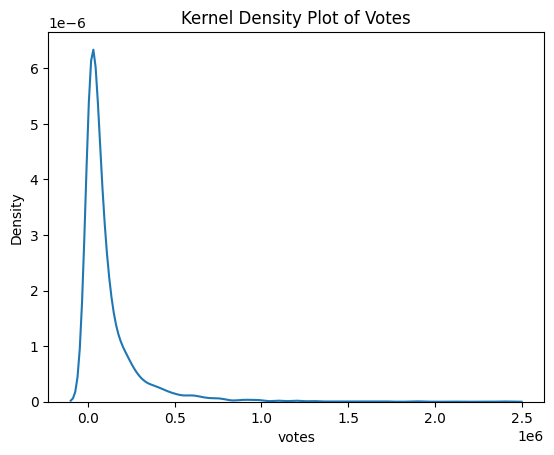

In [37]:
# kde plot - Votes
sns.kdeplot(movies, x = "votes")
plt.title("Kernel Density Plot of Votes")
plt.show()

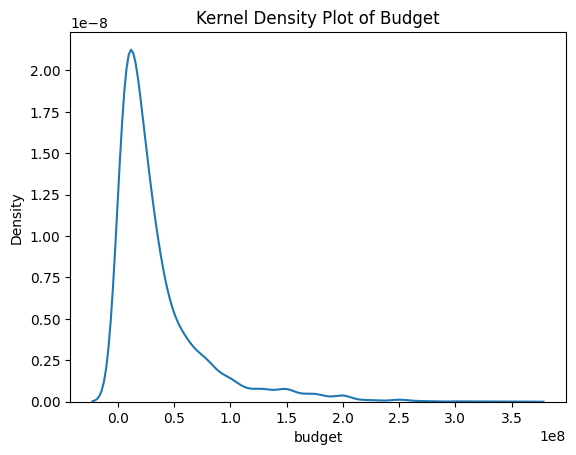

In [38]:
# kde plot - Budget
sns.kdeplot(movies, x = "budget")
plt.title("Kernel Density Plot of Budget")
plt.show()

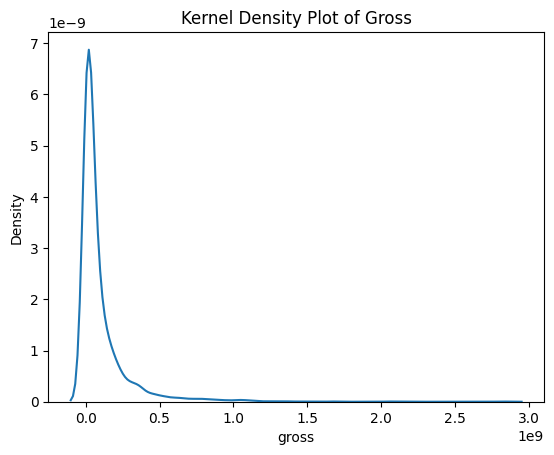

In [39]:
# kde plot - Gross
sns.kdeplot(movies, x = "gross")
plt.title("Kernel Density Plot of Gross")
plt.show()

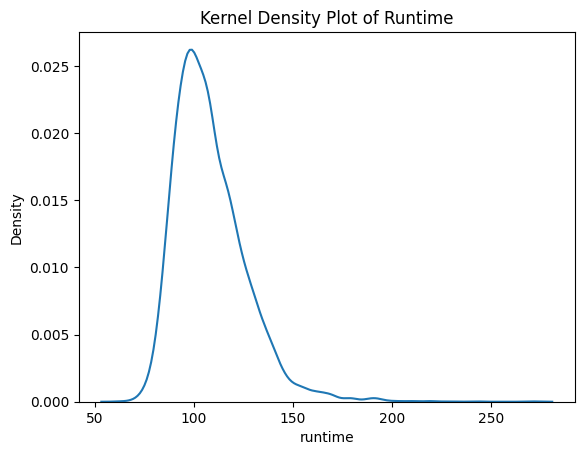

In [40]:
# kde plot - Runtime
sns.kdeplot(movies, x = "runtime")
plt.title("Kernel Density Plot of Runtime")
plt.show()

Runtime looks fine, but the other 3 plots show that the above numeric variables (especially votes, budget, and gross) are right-skewed. Let's apply log transformations to each:

In [41]:
movies["log_gross"] = np.log(movies["gross"])
movies["log_budget"] = np.log(movies["budget"])
movies["log_votes"] = np.log(movies["votes"])

Now let's check the outliers for those variables:

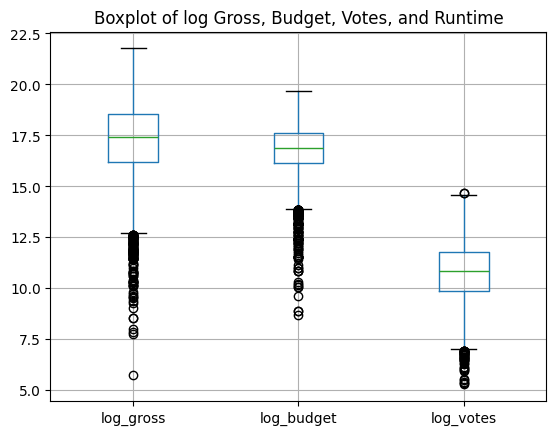

In [42]:
movies.boxplot(column=["log_gross", "log_budget", "log_votes"])
plt.title("Boxplot of log Gross, Budget, Votes, and Runtime")
plt.show()

There are obviously outliers, but since we already log transformed the variables, they still aren't completely extreme values and the skew has already been dealt with.

Next, let's decide what our target and feature variables are:

- Target Variable: Gross (what we are trying to predict) -- and techincally we're using log_gross
- Numeric Features = log_budget, log_votes, score, log_runtime, year
- Categorical Features = genre, rating (could also do country, but there's 50 unique values, which would be hard to one-hot encode)

And then do some EDA:

**Distribution of Target**

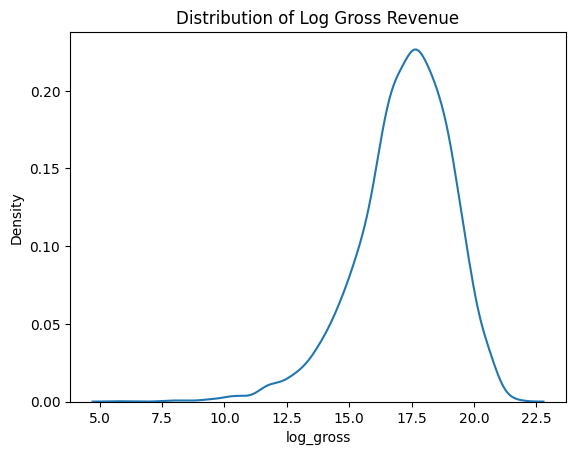

In [43]:
sns.kdeplot(movies["log_gross"])
plt.title("Distribution of Log Gross Revenue")
plt.show()

**Budget vs Revenue**

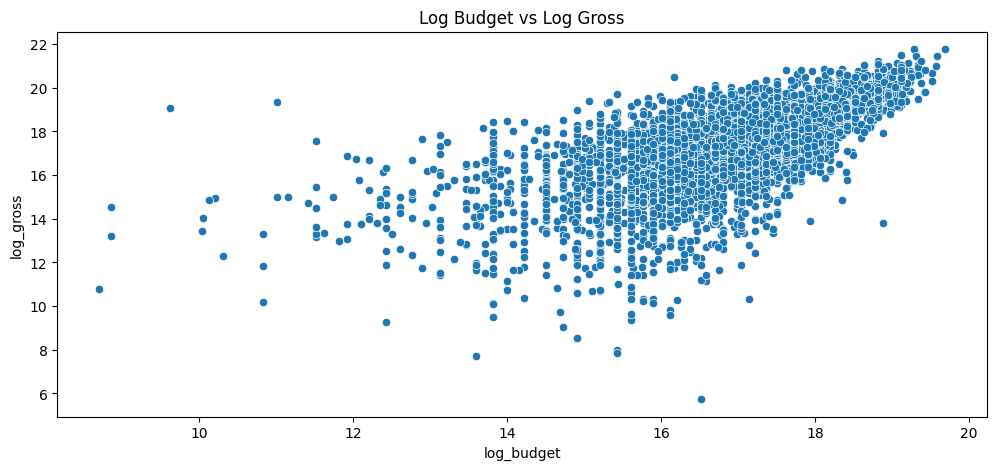

In [44]:
plt.figure(figsize=(12,5))
sns.scatterplot(movies, x="log_budget", y="log_gross")
plt.title("Log Budget vs Log Gross")
plt.show()

There definitely seems to be some sort of positive relationship between budget and gross, which makes sense since higher budgets tend to bring in more revenue.

**Votes vs Revenue:**

Votes refers to the "number of user votes" of the movie

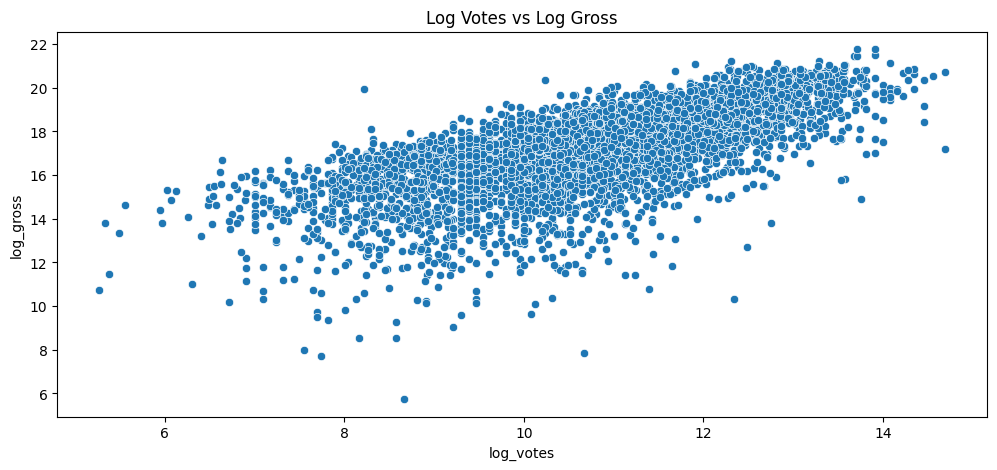

In [45]:
plt.figure(figsize=(12,5))
sns.scatterplot(movies, x="log_votes", y="log_gross")
plt.title("Log Votes vs Log Gross")
plt.show()

A similar positive relationship

**Genre and Score**

For reference, the score refers to the IMBD user score of the movie, which we could also be a potential target variable (we'll keep it a feature for now)

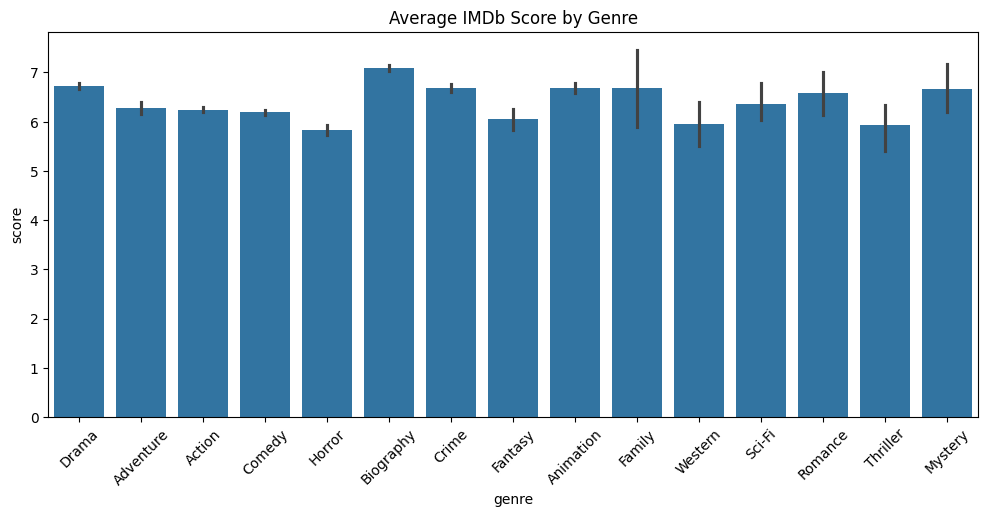

In [46]:
plt.figure(figsize=(12,5))
sns.barplot(movies, x="genre", y="score")
plt.xticks(rotation=45)
plt.title("Average IMDb Score by Genre")
plt.show()

**Revenue across Genres:**

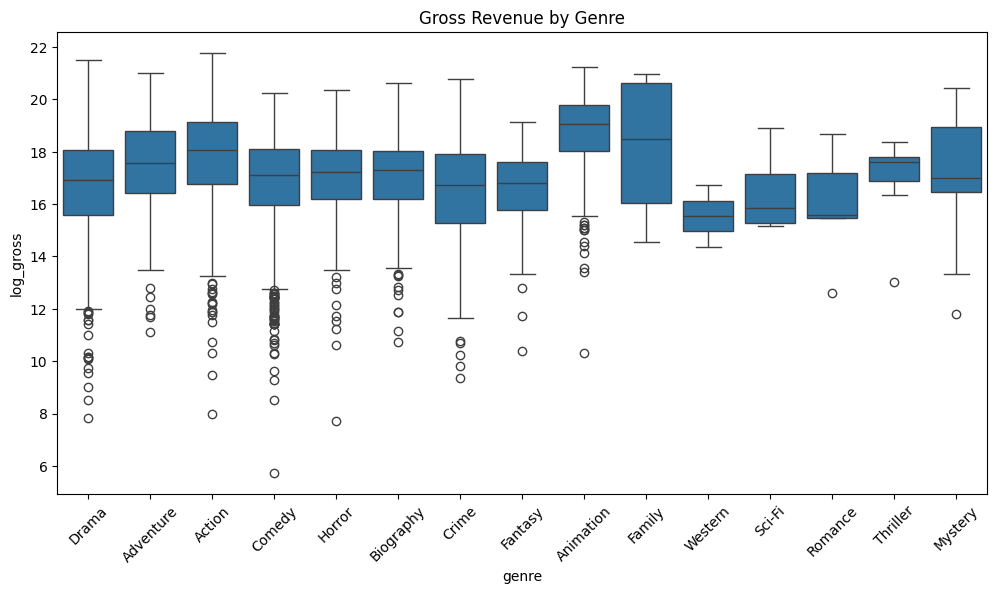

In [47]:
plt.figure(figsize=(12,6))
sns.boxplot(movies, x="genre", y="log_gross")
plt.xticks(rotation=45)
plt.title("Gross Revenue by Genre")
plt.show()

Looks relatively even across the board, with animation movies having the highest median log_gross.

**Revenue by Ratings**

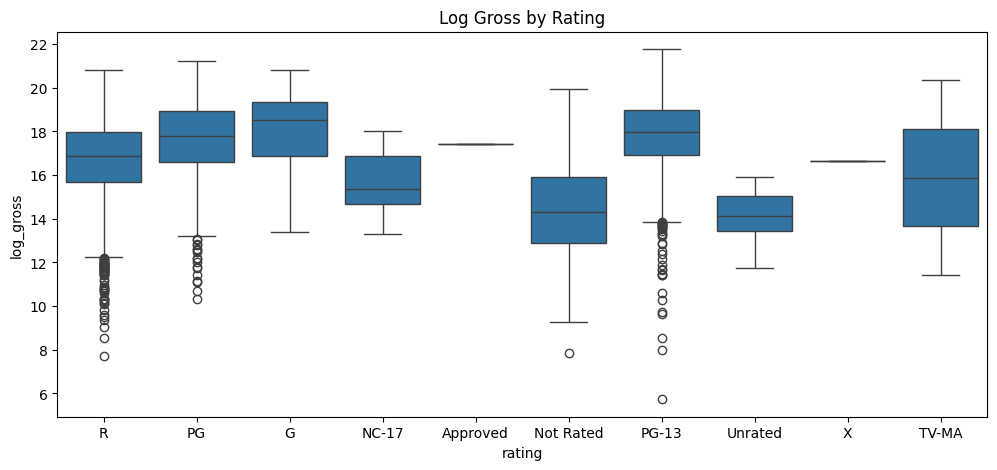

In [48]:
plt.figure(figsize=(12,5))
sns.boxplot(movies, x="rating", y="log_gross")
plt.title("Log Gross by Rating")
plt.show()

Appears that G-rated movies have the highest median log_gross revenue, but other ratings like PG-13 and PG can also rack in high-revenue movies (so can R, but they also have a lot of flop movies)

**Budgets by Genre**

/workspaces/week_8/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 48.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 64.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 27.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/workspaces/week_8/.venv/lib/python3.12/site-packages/seabor

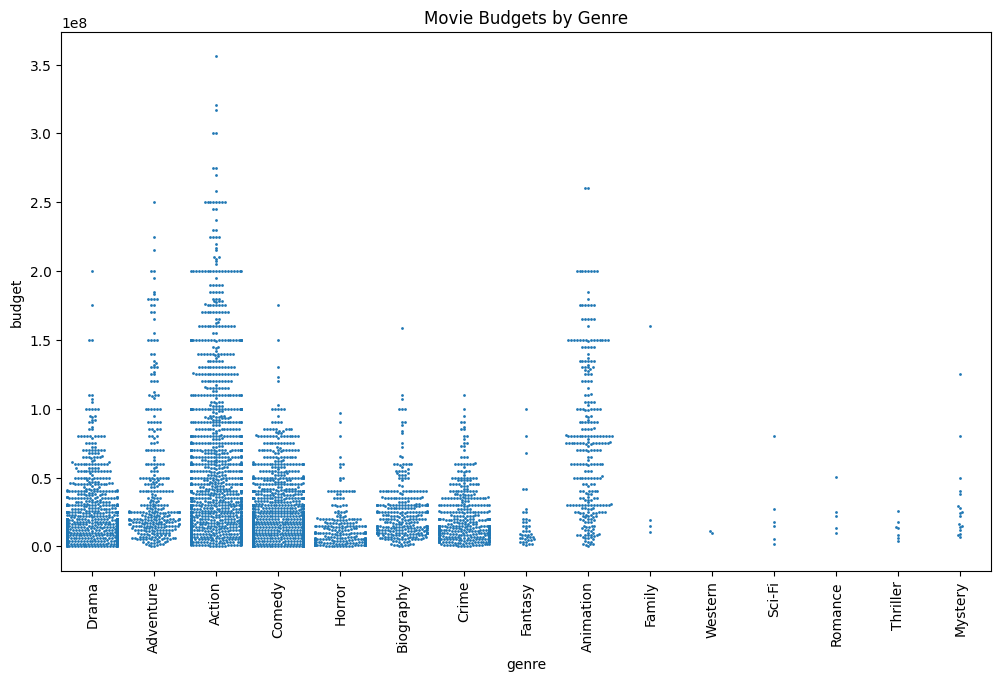

In [49]:
plt.figure(figsize=(12,7))
sns.swarmplot(movies, x="genre", y="budget", size=2)  # not using log_budget to see the differences more easily
plt.xticks(rotation=90)
plt.title("Movie Budgets by Genre")
plt.show()

Action and adventure movies seem to have the highest budgets most often.

##### 3. Split the sample into an ~80% training set and a ~20% test set.

(will do this below for each regression)

##### 4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.

- **Model 1: Numeric Features**
- **Model 2: Categorical Features**
- **Model 3: Partial Combination**
- **Model 4: Full Combination**

Variables defined below:

In [50]:
# Target Variable
y = movies["log_gross"]

# Model 1 - Numeric Only
numeric_features = ["log_budget", "log_votes", "score", "runtime", "year"]

X_num = movies[numeric_features]

# Model 2 - Categorical Only
categorical_features = ["genre", "rating"]

X_cat = pd.get_dummies(movies[categorical_features], drop_first=True)

# Model 3 - Partial Combination from above
partial_combo = ["log_votes", "score", "genre"]  # basically just popularity for numeric, as well as genre

X_partial = movies[partial_combo]
X_partial = pd.get_dummies(X_partial, columns=["genre"], drop_first=True)  # making sure to encode genre

# Model 4 - Full Combination of Numeric and Categorical
X_all = pd.concat([X_num, X_cat], axis=1)


Now we need to split the data into training and testing data sets. To do this, I'll split X_all because it includes all the feature variables in the other models, so I can just create subsets for each one.

In [51]:
# One split
X_train_all, X_test_all, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=83)

In [52]:
# Creating matching splits for each model

# Model 1: Numeric
X_train_num = X_train_all[numeric_features]
X_test_num = X_test_all[numeric_features]

# Model 2: Categorical
X_train_cat = X_train_all.drop(columns=numeric_features)   # dropping numeric to leave all the encoded columns
X_test_cat = X_test_all.drop(columns=numeric_features)

# Model 3: Partial 
X_train_partial = X_partial.loc[X_train_all.index]   # this matches the rows in X_partial with ones in X_all
X_test_partial = X_partial.loc[X_test_all.index]

# And Model 4 is already defined in the train/test split

Now we create and fit the linear regression model, find predictions, and compute the RMSE for each set of features:

In [53]:
# Model 1: Numeric
model_num = LinearRegression().fit(X_train_num, y_train)
y_pred_num = model_num.predict(X_test_num)
rmse_num = np.sqrt(mean_squared_error(y_test, y_pred_num))

# Model 2: Categorical
model_cat = LinearRegression().fit(X_train_cat, y_train)
y_pred_cat = model_cat.predict(X_test_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))

# Model 3: Partial
model_partial = LinearRegression().fit(X_train_partial, y_train)
y_pred_partial = model_partial.predict(X_test_partial)
rmse_partial = np.sqrt(mean_squared_error(y_test, y_pred_partial))

# Model 4: Full
model_all = LinearRegression().fit(X_train_all, y_train)
y_pred_all = model_all.predict(X_test_all)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))

# Print results
print(f"Numeric RMSE: {rmse_num:.4f}")
print(f"Categorical RMSE: {rmse_cat:.4f}")
print(f"Partial RMSE: {rmse_partial:.4f}")
print(f"Full RMSE: {rmse_all:.4f}")

Numeric RMSE: 1.0774
Categorical RMSE: 1.7374
Partial RMSE: 1.2347
Full RMSE: 1.0497


##### 5. Which model performed the best, and why?

As expected, the full model that includes both the numeric and categorical features variables I chose performed the best with an RMSE of 1.0497. This model has the best predictive power because it incorporated both types of feature variables, but we can see from the other models that numeric variables drive most of the model's accuracy. The numeric model had the second lowest RMSE at 1.0774, wheras the categorical model has the lowest RMSE by far at 1.7374. This information tells us that numeric features perform significantly better, with variables like budget and votes being able to capture variation in movie revenue. As for the partial model with and RMSE of 1.2347, it showed moderate performance but lacked key predictors like budget. Overall, combining numeric and categorical features lead to the most accurate predictions. 

##### 6. What did you learn?

Let's first create a correlation matrix to see which numeric variables correlate best to the target variable (log_gross)

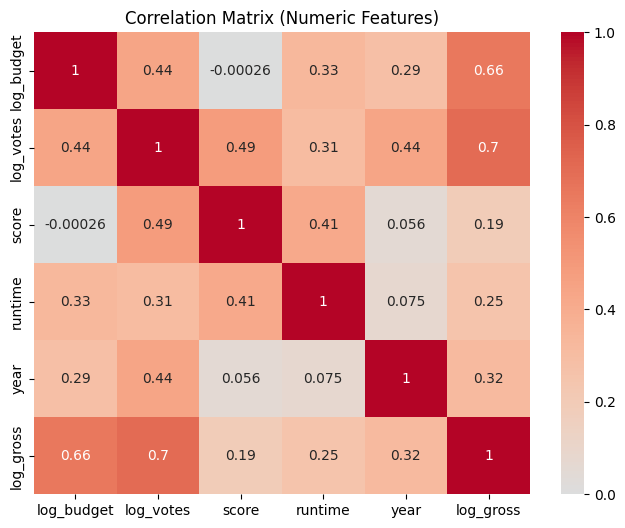

In [ ]:
corr_matrix = movies[numeric_features + ["log_gross"]].corr()   # including numeric features + the target

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

Now here are some key takeaways from the EDA, the linear regression models, and the correlation matrix:

- It was incredibly important to log transform gross, budget, votes, and runtime because of how right-skewed they were (better than arcsinh transformation because we're dealing with positively skewed data with large variations in magnitude). Right-skewed data is bad for linear regression because extreme values would pull the regression line away from the bulk of the data, leading to poor prediction accuracy.

- Budget and votes have the strongest relationship on the gross revenue of a movie out of the numeric variables, as refelcted in their respective scatterplots and their correlation with the target variable (0.66 for log_budget and 0.7 for log_votes). I was actually surprised when I saw this;  I initially thought that budget would have a bigger impact on revenue, but the difference with votes is still pretty close. Overall, if I'm looking to predict the gross revenue of a movie, I would look at the movie's budget and user votes first.

- From the correlation matrix, I was also surprised that user score had a low correlation with gross revenue; in fact, it had the lowest correlation out of all the numeric variables tested (even year!)

- The categorical feature variables of genre and rating perform worse in a linear regression model, while the numeric variables of votes, budget, runtime, score, and year create a more accurate model that can predict gross revenue. However, when combining all these variables, the model performs better than either of the two separate ones. Despite this, if I were to move foward with this model, I would still need to assess its complexity and cost, since there really isn't a big dropoff in accuracy between the numeric model and the full combined model.